In [2]:
# ================================================
# Projet : Poverty Mapping Togo — Python Version
# Notebook : 01 - Data Exploration
# Auteur : Womenyao Komla Sedzro EKLOU
# Date : Mai 2026
# Objectif : Reproduire le projet R en Python
# ================================================

# Import des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✓ Librairies chargées !")
print(f"NumPy version : {np.__version__}")
print(f"Pandas version : {pd.__version__}")

✓ Librairies chargées !
NumPy version : 2.3.5
Pandas version : 2.3.3


In [3]:
# ================================================
# 1. Chargement des données
# ================================================

# Charger le dataset ML des clusters DHS
df = pd.read_csv(
    r"D:\DOCUMENTS FUJITSU\Documents\TRAVAUX_R\POVERTY_MAPPING_TOGO\poverty_mapping_togo\data\processed\dataset_ml_clusters.csv"
)

# Vérification
print("Dataset chargé !")
print(f"Dimensions : {df.shape[0]} clusters x {df.shape[1]} variables")
print("\nAperçu des premières lignes :")
df.head()

Dataset chargé !
Dimensions : 169 clusters x 8 variables

Aperçu des premières lignes :


,hv001,precip_annual,temp_annual,elevation,population,wealth_score,wealth_index,n_menages
0,1,83.166667,27.441666,29,118.843651,131432.307692,5.0,26
1,2,83.916667,27.283334,34,77.718529,127954.782609,5.0,23
2,3,82.916667,27.433333,32,111.444260,121572.214286,5.0,28
3,4,83.666667,27.341667,38,100.291763,110355.962963,5.0,27
4,5,81.666667,27.208333,27,112.871353,123850.857143,4.5,28


In [4]:
# ================================================
# 2. Exploration des données
# ================================================

# Informations générales
print("=== Informations du dataset ===")
print(df.info())

print("\n=== Statistiques descriptives ===")
df.describe()

=== Informations du dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hv001          169 non-null    int64  
 1   precip_annual  169 non-null    float64
 2   temp_annual    169 non-null    float64
 3   elevation      169 non-null    int64  
 4   population     169 non-null    float64
 5   wealth_score   169 non-null    float64
 6   wealth_index   169 non-null    float64
 7   n_menages      169 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 10.7 KB
None

=== Statistiques descriptives ===


,hv001,precip_annual,temp_annual,elevation,population,wealth_score,wealth_index,n_menages
count,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000
mean,86.207101,94.268738,26.933728,200.769231,19.094867,1803.072589,2.902367,28.745562
std,49.652947,13.193860,0.927006,168.737610,32.738809,83088.206293,1.343279,1.596237
min,1.000000,75.250000,22.533333,0.000000,0.125700,-95625.400000,1.000000,23.000000
25%,44.000000,83.750000,26.450000,39.000000,0.623991,-70032.000000,2.000000,28.000000
50%,86.000000,89.250000,27.033333,173.000000,2.576017,-29492.933333,3.000000,29.000000
75%,129.000000,103.583333,27.450000,305.000000,13.601936,82378.461538,4.000000,30.000000
max,171.000000,140.083333,28.841667,847.000000,118.843651,200448.586207,5.000000,30.000000


In [5]:
# ================================================
# 3. Vérification des valeurs manquantes
# ================================================

print("=== Valeurs manquantes par variable ===")
print(df.isnull().sum())

print("\n=== Pourcentage de valeurs manquantes ===")
print(round(df.isnull().sum() / len(df) * 100, 2))

=== Valeurs manquantes par variable ===
hv001            0
precip_annual    0
temp_annual      0
elevation        0
population       0
wealth_score     0
wealth_index     0
n_menages        0
dtype: int64

=== Pourcentage de valeurs manquantes ===
hv001            0.0
precip_annual    0.0
temp_annual      0.0
elevation        0.0
population       0.0
wealth_score     0.0
wealth_index     0.0
n_menages        0.0
dtype: float64


In [6]:
import os
os.makedirs("outputs", exist_ok=True)

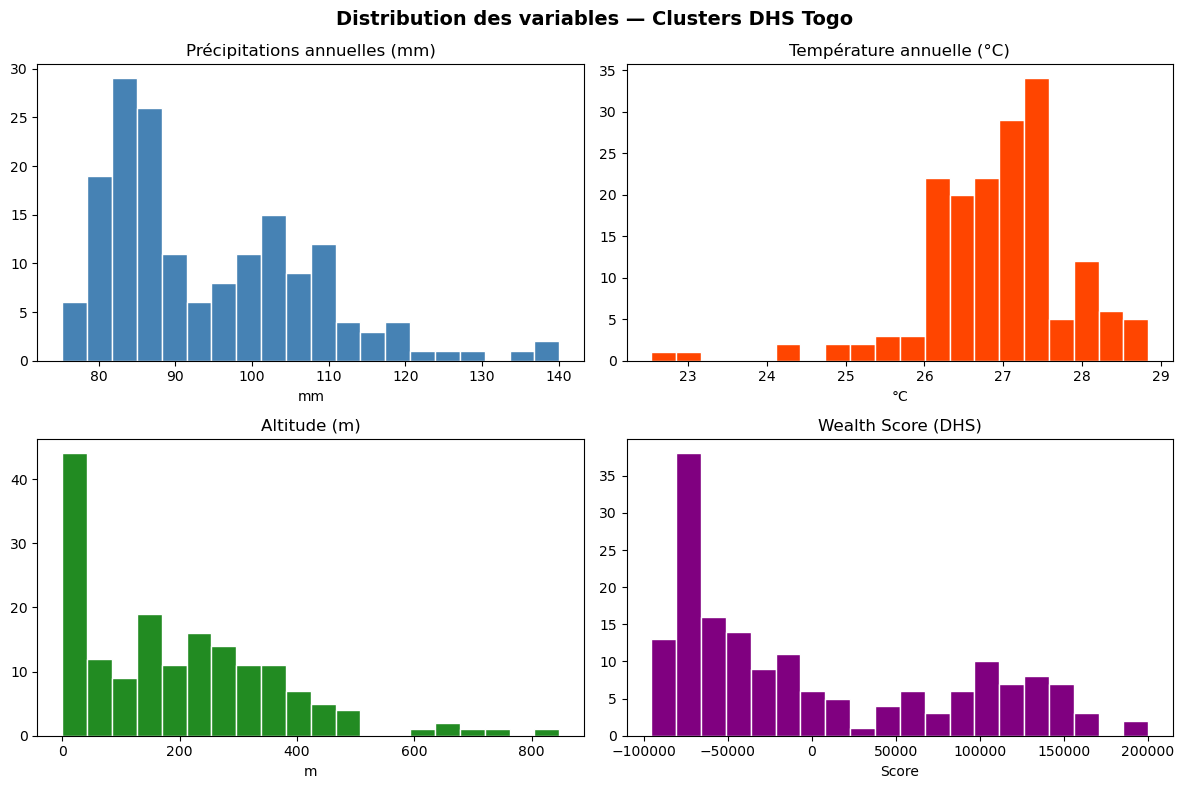

✓ Graphique sauvegardé !


In [7]:
# ================================================
# 4. Visualisation des distributions
# ================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution des variables — Clusters DHS Togo", 
             fontsize=14, fontweight='bold')

# Précipitations
axes[0,0].hist(df['precip_annual'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title("Précipitations annuelles (mm)")
axes[0,0].set_xlabel("mm")

# Température
axes[0,1].hist(df['temp_annual'], bins=20, color='orangered', edgecolor='white')
axes[0,1].set_title("Température annuelle (°C)")
axes[0,1].set_xlabel("°C")

# Altitude
axes[1,0].hist(df['elevation'], bins=20, color='forestgreen', edgecolor='white')
axes[1,0].set_title("Altitude (m)")
axes[1,0].set_xlabel("m")

# Wealth score
axes[1,1].hist(df['wealth_score'], bins=20, color='purple', edgecolor='white')
axes[1,1].set_title("Wealth Score (DHS)")
axes[1,1].set_xlabel("Score")

plt.tight_layout()
plt.savefig("outputs/01_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé !")

=== Matrice de corrélation ===
               precip_annual  temp_annual  elevation  population  wealth_score
precip_annual           1.00        -0.72       0.84       -0.47         -0.34
temp_annual            -0.72         1.00      -0.58        0.21          0.07
elevation               0.84        -0.58       1.00       -0.50         -0.38
population             -0.47         0.21      -0.50        1.00          0.81
wealth_score           -0.34         0.07      -0.38        0.81          1.00


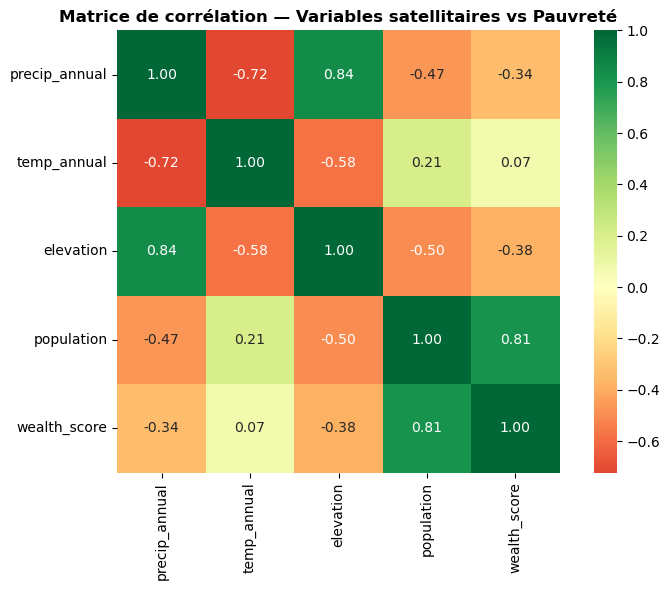

✓ Matrice de corrélation sauvegardée !


In [7]:
# ================================================
# 5. Matrice de corrélation
# ================================================

import seaborn as sns

# Sélectionner les variables numériques
vars_numeriques = ['precip_annual', 'temp_annual', 
                   'elevation', 'population', 'wealth_score']

# Calculer la corrélation
corr_matrix = df[vars_numeriques].corr()

print("=== Matrice de corrélation ===")
print(round(corr_matrix, 2))

# Visualiser
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot    = True,      # afficher les valeurs
    fmt      = ".2f",     # 2 décimales
    cmap     = "RdYlGn",  # rouge → jaune → vert
    center   = 0,         # centrer sur 0
    square   = True       # cellules carrées
)
plt.title("Matrice de corrélation — Variables satellitaires vs Pauvreté",
          fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig("outputs/02_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Matrice de corrélation sauvegardée !")

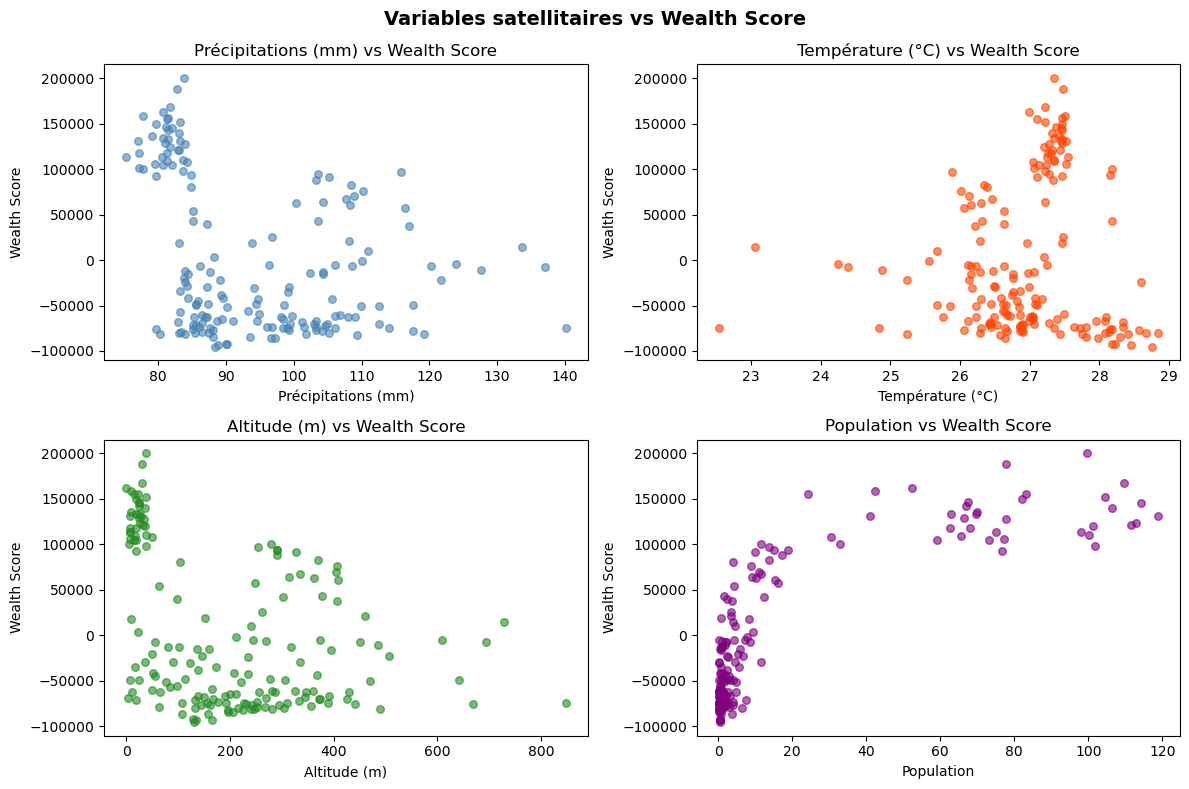

✓ Scatter plots sauvegardés !


In [8]:
# ================================================
# 6. Relations variables vs wealth score
# ================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Variables satellitaires vs Wealth Score", 
             fontsize=14, fontweight='bold')

variables = ['precip_annual', 'temp_annual', 'elevation', 'population']
couleurs  = ['steelblue', 'orangered', 'forestgreen', 'purple']
titres    = ['Précipitations (mm)', 'Température (°C)', 
             'Altitude (m)', 'Population']

for i, (var, couleur, titre) in enumerate(zip(variables, couleurs, titres)):
    row, col = i // 2, i % 2
    axes[row, col].scatter(
        df[var], df['wealth_score'],
        color=couleur, alpha=0.6, s=30
    )
    axes[row, col].set_xlabel(titre)
    axes[row, col].set_ylabel("Wealth Score")
    axes[row, col].set_title(f"{titre} vs Wealth Score")

plt.tight_layout()
plt.savefig("outputs/03_scatter_plots.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plots sauvegardés !")

In [9]:
# ================================================
# 7. Modèle XGBoost
# ================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# Variables prédictives et cible
X = df[['precip_annual', 'temp_annual', 'elevation', 'population']]
y = df['wealth_score']

print(f"Variables prédictives : {X.shape[1]}")
print(f"Observations : {X.shape[0]}")

Variables prédictives : 4
Observations : 169


In [10]:
# ================================================
# 8. Split train/test + Entraînement XGBoost
# ================================================

# Split train/test (70/30 comme dans R)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.3,
    random_state = 777
)

print(f"Train : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")

# Normalisation
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Modèle XGBoost
model = xgb.XGBRegressor(
    n_estimators = 15,
    max_depth    = 2,
    random_state = 777
)

# Entraînement
model.fit(X_train, y_train)

print("\n✓ Modèle entraîné !")

Train : 118 observations
Test  : 51 observations

✓ Modèle entraîné !


=== Performance du modèle XGBoost ===
R²   : 0.887
RMSE : 31181
MAE  : 24597


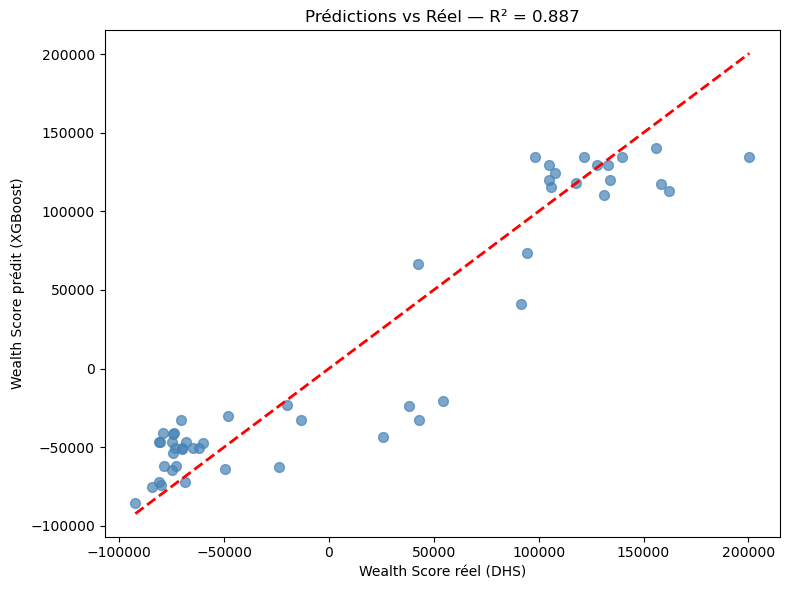

✓ Graphique sauvegardé !


In [11]:
# ================================================
# 9. Évaluation du modèle
# ================================================

# Prédictions
y_pred = model.predict(X_test)

# Métriques
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mae  = np.mean(np.abs(y_test - y_pred))

print("=== Performance du modèle XGBoost ===")
print(f"R²   : {r2:.3f}")
print(f"RMSE : {rmse:.0f}")
print(f"MAE  : {mae:.0f}")

# Visualisation prédictions vs réel
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7, s=50)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', lw=2)
plt.xlabel("Wealth Score réel (DHS)")
plt.ylabel("Wealth Score prédit (XGBoost)")
plt.title(f"Prédictions vs Réel — R² = {r2:.3f}")
plt.tight_layout()
plt.savefig("outputs/04_predictions_vs_real.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé !")

=== Importance des variables ===
        Variable  Importance
2      elevation    0.028397
1    temp_annual    0.076368
0  precip_annual    0.086971
3     population    0.808264


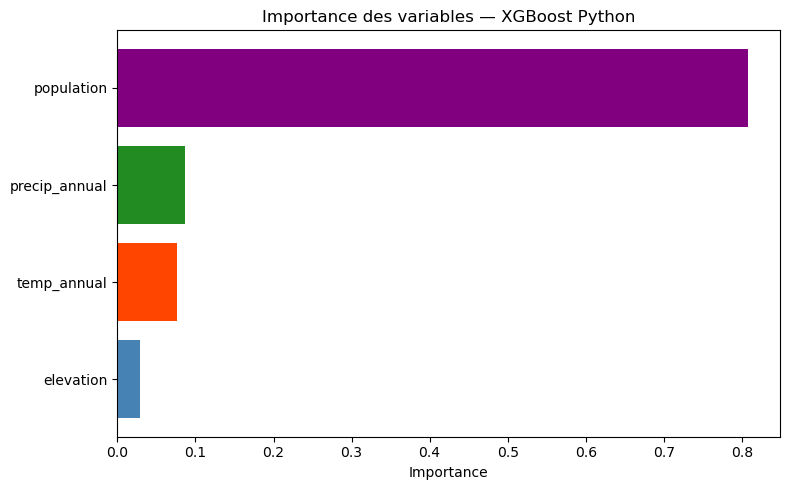

In [12]:
# ================================================
# 10. Importance des variables
# ================================================

# Extraire l'importance
importance = pd.DataFrame({
    'Variable'  : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

print("=== Importance des variables ===")
print(importance)

# Visualiser
plt.figure(figsize=(8, 5))
plt.barh(
    importance['Variable'],
    importance['Importance'],
    color=['steelblue', 'orangered', 'forestgreen', 'purple']
)
plt.xlabel("Importance")
plt.title("Importance des variables — XGBoost Python")
plt.tight_layout()
plt.savefig("outputs/05_variable_importance.png", dpi=300, bbox_inches='tight')
plt.show()